In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))
    
def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])
    

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:

cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(30,41)},
                    'Thermo': np.arange(30,41)}
                    
fn_range = np.arange(-.9, 0.9, 0.05)

In [5]:
curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'LuNER', 'Thermo')

test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_test_pred_df.csv'))
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
print(test_pred.shape)
test_pred = (test_pred
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)


(6175, 4)
(6175, 7)


In [70]:
def convert_df(df):
    try:
        df['date'] = pd.to_datetime(df.created_date)
    except:
        df['date'] = np.nan
    return df

df = groundtruth_df.merge(join_df.loc[(join_df.cycle_no == 1), 
                                      ['curve_idx','created_date']])
dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
dt_df.groupby('split').agg(max_date = ('date','max'),
                           min_date = ('date', 'min'))

/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-ex

In [6]:

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_retest_pred_df.csv'))
# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_retest_pred_df.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_pred = (retest_pred
               .merge(retest_groundtruth[['curve_idx','target','sample_id','groundtruth_target','igi_call']]
                      .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna())]
                        #   (~retest_groundtruth.target.isin(['RnaseP','MS2']))]
                          )
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
# )
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)


(4084, 4)
(3948, 9)


In [74]:

df = retest_pred.merge(join_df.loc[(join_df.cycle_no == 1), 
                                      ['curve_idx','created_date']])
dt_df = df.groupby(['created_date']).apply(func=convert_df).reset_index(drop=True)
dt_df.agg(max_date = ('date','max'),
                           min_date = ('date', 'min'))

/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.created_date)
/tmp/ipykernel_682234/2855482790.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-ex

,date
max_date,2022-05-13
min_date,2020-08-18


In [7]:
qpcr_test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_test_pred = qpcr_test_pred[qpcr_test_pred.split == 'test']

qpcr_retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))

In [8]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','test_kit']], on='curve_idx')
 .groupby('test_kit').sample_id.nunique()
 )

test_kit
LuNER     848
Thermo    351
Name: sample_id, dtype: int64

In [9]:
(retest_pred
 .merge(join_df.loc[join_df.cycle_no == 1,['curve_idx','current_sample_result']], on='curve_idx')
 .groupby('current_sample_result').sample_id.nunique()
 )

current_sample_result
Inconclusive    314
Invalid         876
Negative          8
Positive          1
Name: sample_id, dtype: int64

In [10]:
# known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

# join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
# thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
# join_df['test_kit'] = 'LuNER'
# join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [11]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
# groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# print(test_pred.shape)
# test_pred = (test_pred
#              .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
#                     .drop_duplicates(),
#                     on='curve_idx')
#              .rename(columns={'prob':'outputs'})
#              )
# print(test_pred.shape)

# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth.loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()) &
#                           (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','groundtruth_target','igi_call']])
#                .rename(columns={#'groundtruth_target':'groundtruth_label',
#                                 'prob':'outputs'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)


In [12]:
# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# print(test_pred[test_pred.split == 'test'].shape)
# test_pred = (test_pred[test_pred.split == 'test']
#              .merge(groundtruth_df.loc[groundtruth_df.cycle_no == 1,['curve_idx','sample_id','igi_call','groundtruth']].drop_duplicates(),
#                     on='curve_idx')
#              )
# print(test_pred.shape)
# test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
# test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

# retest_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_new_retest_1_val_test_pred_df.csv'))
# print(retest_pred.shape)
# retest_groundtruth = pd.read_csv(os.path.join(new_data_dir, 'new_retest_df_target_data_1.csv'))
# retest_pred = (retest_pred
#                .merge(retest_groundtruth
#                       .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
#                           (~retest_groundtruth.final_patient_result.isna()) &
#                           (~retest_groundtruth.target.isin(['RnaseP','MS2'])),
#                           ['curve_idx','sample_id','groundtruth_target','igi_call']])
#                .rename(columns={'groundtruth_target':'groundtruth_label'}))
# retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
# print(retest_pred.shape)

In [13]:
summary_table(test_pred)

,n_curves,pos_perc,n_sample
0,6175,0.899109,5517


In [14]:
summary_table(retest_pred)

,n_curves,pos_perc,n_sample
0,3948,0.37386,1199


### vary model threshold

In [15]:
model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_pred['pred'] = 1*(test_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
    

In [16]:
best_acc_threshold_idx = model_dict_df.acc.idxmax()
best_acc_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Best Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('Best Accuracy Threshold on Test:', best_acc_threshold)

Best Accuracy on Test: 0.9872064777327936
Best Accuracy Threshold on Test: 0.5660000000000001


In [17]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)
print('Model AUC on test set:', model_test_auc)
test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
calc_metrics(test_pred.groundtruth_label, test_pred.pred)

Number of Na predictions in test set: 0
Model AUC on test set: 0.997836882057165


,acc,f1,tn,fp,fn,tp
0,0.987206,0.992878,589,34,45,5507


In [18]:
igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
igi_true_pos_frac = sum(test_pred.encoded_igi_call == 1)/test_pred.shape[0]
print('IGI true positive fraction:', igi_true_pos_frac)
print('IGI AUC on test set:', igi_test_auc)
df = calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.8584615384615385
IGI AUC on test set: 0.9773955331412103


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.959352,0.976873,623,0,251,5301,0.045209,0.0


In [19]:
igi_pos_frac_thres = model_dict_df.loc[(model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

test_pred['pred'] = 1*(test_pred.outputs >= igi_pos_frac_thres.loc[0,'thres'])
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.959028,0.976688,622,1,252,5300,0.045389,0.001605


In [20]:
retest_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    retest_model_dict['thres'].append(i)
    retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
retest_model_dict_df = pd.DataFrame(retest_model_dict)
    

In [21]:
print('Number of Na predictions on retest:', retest_pred.outputs.isna().sum())
model_retest_auc = roc_auc_score(retest_pred[~retest_pred.outputs.isna()].groundtruth_label, 
                                 retest_pred[~retest_pred.outputs.isna()].outputs)
print('Model AUC on retest:', model_retest_auc)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)

Number of Na predictions on retest: 0
Model AUC on retest: 0.9382157398637092


,acc,f1,tn,fp,fn,tp
0,0.912867,0.878531,2360,112,232,1244


In [22]:
igi_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
retest_igi_true_pos_frac = sum(retest_pred.encoded_igi_call == 1)/retest_pred.shape[0]
print('IGI true positive fraction:', retest_igi_true_pos_frac)
print('IGI AUC on retest:', igi_retest_auc)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.342451874366768
IGI AUC on retest: 0.7459152261425527


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.77001,0.678925,2080,392,516,960,0.349593,0.158576


In [23]:
retest_model_dict_df.loc[(retest_model_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (retest_model_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
574,0.574,0.912361,0.159214,0.044903,0.342452
575,0.575,0.912361,0.159214,0.044903,0.342452
576,0.576,0.912361,0.159214,0.044903,0.342452
577,0.577,0.912361,0.159214,0.044903,0.342452


In [47]:
retest_igi_pos_frac_thres = 0.574 #0.026 # fusion
# retest_igi_pos_frac_thres = 0.710 # seq
# retest_igi_pos_frac_thres = .reset_index()

retest_pred['pred'] = 1*(retest_pred.outputs >= retest_igi_pos_frac_thres)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('Model')
df



Model


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.912361,0.877652,2361,111,235,1241,0.159214,0.044903


### vary qpcr threshold

In [25]:
qpcr_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_dict['thres'].append(i)
    qpcr_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_dict_df = pd.DataFrame(qpcr_model_dict)
    

In [53]:
qpcr_model_dict_df.loc[(qpcr_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (qpcr_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,631,0.631,0.950769,0.049892,0.043339,0.858623
1,632,0.632,0.950769,0.049892,0.043339,0.858623
2,633,0.633,0.950607,0.050072,0.043339,0.858462


In [55]:
igi_pos_frac_qpcr_thres = 0.633

qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.950607,0.971897,596,27,278,5274,0.050072,0.043339


In [26]:
qpcr_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_retest_dict['thres'].append(i)
    qpcr_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_retest_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_retest_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_retest_dict_df = pd.DataFrame(qpcr_model_retest_dict)
    

In [ ]:
qpcr_model_retest_dict_df.loc[(qpcr_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (qpcr_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
630,0.630,0.777914,0.33774,0.154026,0.342311
631,0.631,0.777914,0.33774,0.154026,0.342311
632,0.632,0.777914,0.33774,0.154026,0.342311
633,0.633,0.777914,0.33774,0.154026,0.342311
634,0.634,0.777914,0.33774,0.154026,0.342311
635,0.635,0.777914,0.33774,0.154026,0.342311
636,0.636,0.777914,0.33774,0.154026,0.342311
637,0.637,0.777914,0.33774,0.154026,0.342311
638,0.638,0.777914,0.33774,0.154026,0.342311
639,0.639,0.777914,0.33774,0.154026,0.342311


In [ ]:
retest_igi_pos_frac_qpcr_thres = 0.63
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= retest_igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.777914,0.688423,2175,396,511,1002,0.33774,0.154026


In [48]:
qpcr_model_retest_dict_df.loc[(qpcr_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (qpcr_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
630,0.630,0.777914,0.33774,0.154026,0.342311
631,0.631,0.777914,0.33774,0.154026,0.342311
632,0.632,0.777914,0.33774,0.154026,0.342311
633,0.633,0.777914,0.33774,0.154026,0.342311
634,0.634,0.777914,0.33774,0.154026,0.342311
635,0.635,0.777914,0.33774,0.154026,0.342311
636,0.636,0.777914,0.33774,0.154026,0.342311
637,0.637,0.777914,0.33774,0.154026,0.342311
638,0.638,0.777914,0.33774,0.154026,0.342311
639,0.639,0.777914,0.33774,0.154026,0.342311


In [52]:
retest_igi_pos_frac_qpcr_thres = 0.63
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= retest_igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.777914,0.688423,2175,396,511,1002,0.33774,0.154026


### vary IGI thresholds
#### test set

##### Move individual pcr plate

In [27]:
full_test_pred = (test_pred
                  .merge(join_df[['curve_idx','target','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn']].drop_duplicates(),
                         on = 'curve_idx'))
full_test_pred['encoded_igi_call'] = 1*(full_test_pred.igi_call == 'Positive')
print(full_test_pred.shape)

(270020, 17)


In [28]:
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

new_thres_df = (full_test_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(thres_ct_df, on=['curve_idx','cycle_no']))
new_thres_df['igi_threshold'] = new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_test_pred = (full_test_pred
                  .merge(new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )
full_test_pred.loc[full_test_pred.igi_threshold.isna(),'igi_threshold'] = full_test_pred.loc[full_test_pred.igi_threshold.isna(),'threshold']
print(full_test_pred.shape)
full_test_pred.head(5)

(270020, 18)


,curve_idx,outputs,igi_fp,igi_fn,sample_id,igi_call,groundtruth,encoded_igi_call,groundtruth_label,pred,target,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,1,178.980698,10249.504305
1,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,2,139.666701,10249.504305
2,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,3,107.274579,10249.504305
3,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,4,80.349253,10249.504305
4,67985,1.0,1.179298e-18,3.064294e-12,S789587,Positive,1,1,1,1,RnaseP,10000.0,AC00GY79,LuNER,28.035708635832776,5,117.570412,10249.504305


#### systematically shift the Fn threshold and Ct

In [29]:
thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_test_pred.copy()
        df['new_threshold'] = full_test_pred.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [30]:
final_thres_df = pd.DataFrame(thres_df)
final_thres_df['fpr_type'] = 'simulated'
final_thres_df['fnr_type'] = 'simulated'


In [31]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fnr = igi_fn/(igi_fn+igi_tp) 
igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
igi_fpr = igi_fp/(igi_fp + igi_tn)
print('Current IGI FNR:', igi_fnr)
print('Current IGI FPR:', igi_fpr)
print('Current IGI positive fraction:', igi_pos_frac)

Current IGI FNR: 0.04520893371757925
Current IGI FPR: 0.0
Current IGI positive fraction: 0.8584615384615385


In [32]:
true_pos_frac = sum(test_pred.groundtruth_label == 1)/test_pred.shape[0]
print('True positive fraction:', true_pos_frac)

True positive fraction: 0.8991093117408907


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on test set')

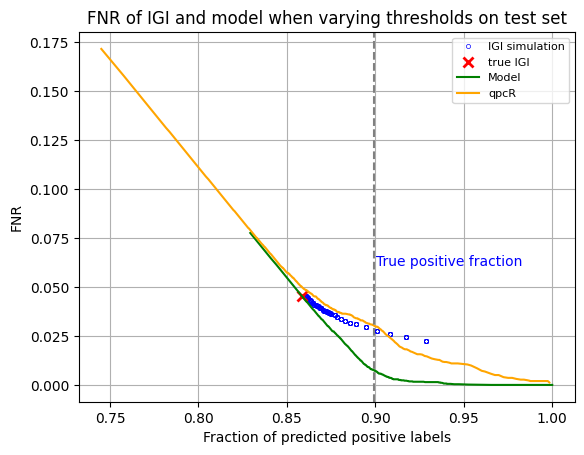

In [33]:

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(model_dict_df.pos_frac, model_dict_df.fnr, color='green', label='Model')

plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fnr, color='orange', label='qpcR')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on test set')

Text(0.5, 1.0, 'FPR of IGI and model when varying thresholds on test set')

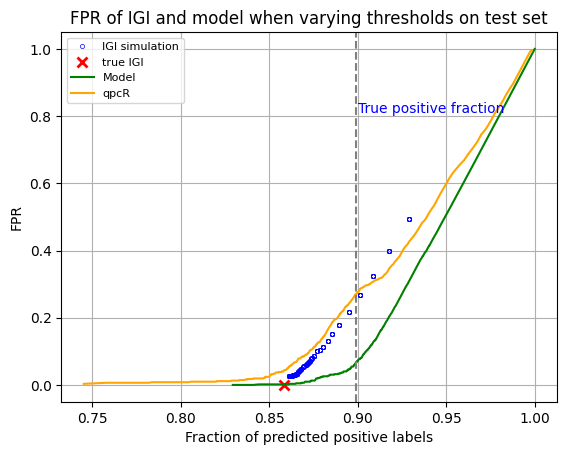

In [34]:

plt.plot(final_thres_df.pos_pred, 
         final_thres_df.fpr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(model_dict_df.pos_frac, model_dict_df.fpr, color='green', label='Model')
plt.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color='orange', label='qpcR')
plt.axvline(true_pos_frac, linestyle='--', color='gray')
plt.text(x=true_pos_frac + 0.001, y = 0.81, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.025,0.15)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.title('FPR of IGI and model when varying thresholds on test set')

In [84]:
# final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_test_final_thres_df.csv', index=False)

#### retest

In [35]:
full_retest_pred = (retest_pred
                  .merge(join_df[['curve_idx','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn']], #
                         on = 'curve_idx'))
# full_retest_pred['encoded_igi_call'] = 1*(full_retest_pred.igi_call == 'Positive')
print(full_retest_pred.shape)

(170640, 16)


In [36]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)


True retest positive fraction: 0.3738601823708207


In [37]:
retest_thres_ct_df = full_retest_pred.loc[full_retest_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
retest_thres_ct_df['cycle_no'] = retest_thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

retest_new_thres_df = (full_retest_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(retest_thres_ct_df, on=['curve_idx','cycle_no']))
retest_new_thres_df['igi_threshold'] = retest_new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_retest_pred = (full_retest_pred
                  .merge(retest_new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )


full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'igi_threshold'] = full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'threshold']
print(full_retest_pred.shape)
full_retest_pred.head(5)

(170640, 17)


,curve_idx,outputs,igi_fp,igi_fn,target,sample_id,groundtruth_label,igi_call,encoded_igi_call,pred,threshold,pcr_plate,test_kit,thres_ct,cycle_no,drn,igi_threshold
0,103812,0.999994,2.539898e-10,0.00001,RnaseP,S1085008,1.0,Positive,1,1,10000.0,AC00H0TY,LuNER,25.67476578,1,-59.372682,10252.029757
1,103812,0.999994,2.539898e-10,0.00001,RnaseP,S1085008,1.0,Positive,1,1,10000.0,AC00H0TY,LuNER,25.67476578,2,-35.402419,10252.029757
2,103812,0.999994,2.539898e-10,0.00001,RnaseP,S1085008,1.0,Positive,1,1,10000.0,AC00H0TY,LuNER,25.67476578,3,8.202610,10252.029757
3,103812,0.999994,2.539898e-10,0.00001,RnaseP,S1085008,1.0,Positive,1,1,10000.0,AC00H0TY,LuNER,25.67476578,4,-20.318338,10252.029757
4,103812,0.999994,2.539898e-10,0.00001,RnaseP,S1085008,1.0,Positive,1,1,10000.0,AC00H0TY,LuNER,25.67476578,5,-3.229911,10252.029757


In [38]:
retest_plate_target_pair = full_retest_pred[['pcr_plate','target','test_kit']].drop_duplicates()


### systematically move Fn thresholds

In [39]:
retest_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(10):
        df = full_retest_pred.copy()
        df['new_threshold'] = df.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        retest_thres_df['fpr'].append(fp/(fp+tn))
        retest_thres_df['fnr'].append(fn/(fn+tp))
        retest_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [40]:
retest_final_thres_df = pd.DataFrame(retest_thres_df)
retest_final_thres_df['fpr_type'] = 'simulated'
retest_final_thres_df['fnr_type'] = 'simulated'


In [41]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)

In [42]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label == 1)/retest_pred.shape[0]

Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on Retest set')

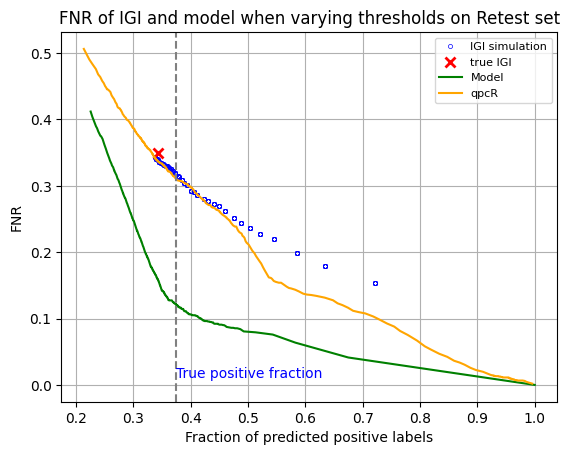

In [43]:

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color='green', label='Model')
plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color='orange', label='qpcR')
plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.001, y = 0.01, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on Retest set')

In [74]:
# plt.style.use('seaborn-v0_8-poster')
# plt.plot(retest_final_thres_df.pos_pred, 
#          retest_final_thres_df.fnr, 
#          '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

# plt.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

# plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr,color='green', label='Model')
# plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
# plt.text(x=true_retest_pos_frac + 0.01, y = 0., s='True positive fraction')
# # plt.xlim(0.3, 0.5)
# # plt.ylim(0.025,0.42)

# plt.xlabel('Fraction of predicted positive labels')
# plt.ylabel('FNR')
# plt.legend(loc='upper right',fontsize=8)
# plt.grid()
# plt.title('FNR of IGI and model when varying thresholds on Retest',family='sans-serif', fontname='Sans',
#           fontsize=14,
#             fontstyle='italic')




Text(0.5, 1.0, 'FPR of IGI and model when varying thresholds on Retest')

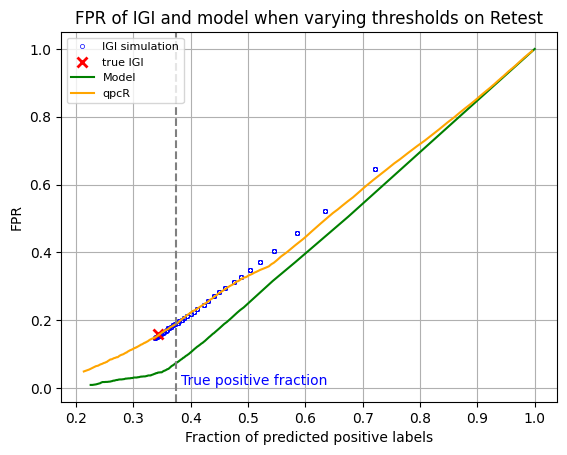

In [45]:

plt.plot(retest_final_thres_df.pos_pred, 
         retest_final_thres_df.fpr, 
         '.', **{'mfc': 'none', 'mec':'blue','mew':0.5}, label='IGI simulation')

plt.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, color='green', label='Model')
plt.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fpr, color='orange', label='qpcR')
plt.axvline(true_retest_pos_frac, linestyle='--', color='gray')
plt.text(x=true_retest_pos_frac + 0.01, y = 0.01, s='True positive fraction', c='blue')
# plt.xlim(0.3, 0.5)
# plt.ylim(0,0.4)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.title('FPR of IGI and model when varying thresholds on Retest')

In [151]:
retest_final_thres_df.to_csv('/media/ssd1/huong/PCR-huong/data/paper_plots/paper_plots_retest_final_thres_df.csv', index=False)